<a href="https://colab.research.google.com/github/RandimaAlexander/churn-analysis/blob/main/customer_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Retention & Churn Risk Analysis**

**Business Problem**

Customer churn leads to revenue loss and increased customer acquisition costs.
This project aims to identify high-risk customers and understand the key drivers of churn to support retention strategies.

**Dataset** -
IBM Telco Customer Churn Dataset (7000+ customers with demographic, service, and billing information)

**PHASE 1 - Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the Excel file
file_path = "/content/Telco_customer_churn.xlsx"
df = pd.read_excel(file_path)

print("Loaded")
print("Shape (rows, cols):", df.shape)
df.head()


Loaded
Shape (rows, cols): (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


**PHASE 2 - Understand the Dataset**

In [ ]:
#Task 2.1 — Check column names
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
#Task 2.2 — Check data types
df.dtypes

,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


In [ ]:
#Task 2.3 — Check missing values
df.isna().sum().sort_values(ascending=False).head(15)


,0
Churn Reason,5174
CustomerID,0
Count,0
State,0
Country,0
Zip Code,0
Lat Long,0
Latitude,0
City,0
Gender,0


**PHASE 3 - Define the “Churn” Target**

In [ ]:
#Task 3.1
#Churn Value (1 = churn, 0 = stay)
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [ ]:
#Task 3.2 — Calculate churn rate
churn_rate = df['Churn Value'].mean() * 100
churn_rate

np.float64(26.536987079369588)

**PHASE 4 - Basic Cleaning**

In [ ]:
#Task 4.1 — Fix Total Charges / Monthly Charge types
for col in ['Monthly Charges', 'Total Charges', 'CLTV', 'Churn Score']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df[['Monthly Charges','Total Charges','CLTV','Churn Score']].isna().sum()


,0
Monthly Charges,0
Total Charges,11
CLTV,0
Churn Score,0


In [ ]:
#Task 4.2 — Drop rows missing key values
df_clean = df.dropna(subset=['Churn Value', 'Monthly Charges', 'Total Charges'])
print(df_clean.shape)


(7032, 33)


**PHASE 5 - Core Analysis**

In [ ]:
#Task 5.1 — Churn by Contract Type
pd.crosstab(df_clean['Contract'], df_clean['Churn Value'], normalize='index') * 100


Churn Value,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [ ]:
#Task 5.2 — Churn by Tenure
df_clean.groupby('Churn Value')['Tenure Months'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


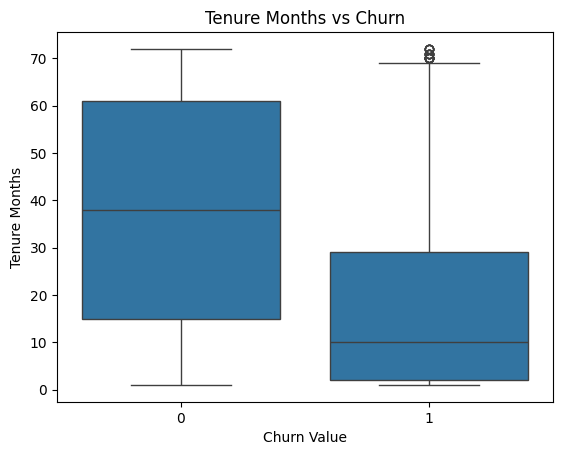

In [ ]:
#Task 5.3 — Plot tenure vs churn
import seaborn as sns
sns.boxplot(x='Churn Value', y='Tenure Months', data=df_clean)
plt.title("Tenure Months vs Churn")
plt.show()


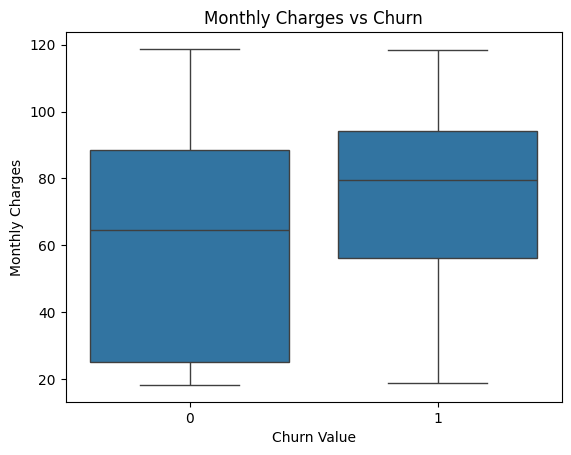

In [ ]:
#Task 5.4 — Monthly Charge vs churn
sns.boxplot(x='Churn Value', y='Monthly Charges', data=df_clean)
plt.title("Monthly Charges vs Churn")
plt.show()


**PHASE 6 - Risk Segmentation**

In [43]:
#Task 6.1 — Create churn risk buckets using Churn Score
df_clean = df_clean.copy()
df_clean.loc[:, 'Risk Segment'] = pd.cut(
    df_clean['Churn Score'],
    bins=[-1, 33, 66, 100],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df_clean['Risk Segment'].value_counts()

,count
Risk Segment,
High Risk,2981
Medium Risk,2861
Low Risk,1190


In [44]:
#Task 6.2 — Check churn rate by risk segment
df_clean.groupby('Risk Segment')['Churn Value'].mean() * 100

/tmp/ipykernel_165/48140213.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('Risk Segment')['Churn Value'].mean() * 100


,Churn Value
Risk Segment,
Low Risk,0.000000
Medium Risk,3.565187
High Risk,59.275411


**PHASE 7 — Business Angle**

In [ ]:
#Task 7.1 — Compare CLTV for churned vs not churned
df_clean.groupby('Churn Value')['CLTV'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,4492.679837,1166.653300,2003.0,3649.0,4620.0,5436.0,6500.0
1,1869.0,4149.414660,1189.370707,2003.0,3101.0,4238.0,5166.0,6484.0


In [ ]:
#Task 7.2 — Identify “High-Value churners”
threshold = df_clean['CLTV'].quantile(0.75)  # top 25%
high_value_churners = df_clean[(df_clean['CLTV'] >= threshold) & (df_clean['Churn Value'] == 1)]
high_value_churners.shape


(365, 34)

/tmp/ipykernel_165/304750697.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_churn = df_clean.groupby('Risk Segment')['Churn Value'].mean() * 100


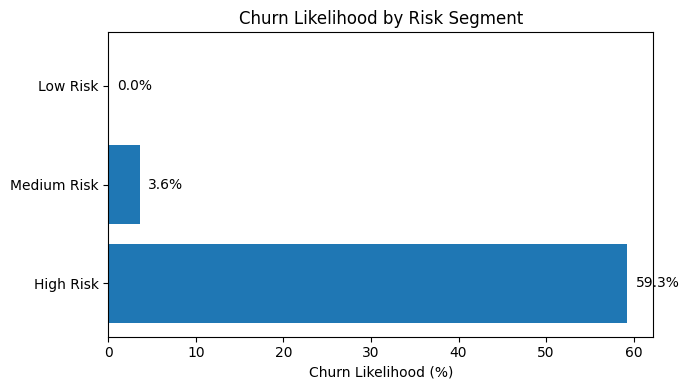

In [ ]:
import matplotlib.pyplot as plt


# Calculate churn % per risk segment
risk_churn = df_clean.groupby('Risk Segment')['Churn Value'].mean() * 100

# Order properly
risk_churn = risk_churn.reindex(["Low Risk", "Medium Risk", "High Risk"])

# Plot
plt.figure(figsize=(7,4))
bars = plt.barh(risk_churn.index, risk_churn.values)

plt.title("Churn Likelihood by Risk Segment")
plt.xlabel("Churn Likelihood (%)")

# Add % labels
for i, v in enumerate(risk_churn.values):
    plt.text(v + 1, i, f"{v:.1f}%", va='center')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**PHASE 8 - Select Features**

In [45]:
# Dropping irrelevant / leakage columns
drop_cols = [
    "CustomerID", "Count", "Country", "State", "City", "Zip Code",
    "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Reason", "Churn Score"  # remove leakage
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df["Churn Value"]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (7043, 22)
y shape: (7043,)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV,Risk_Level
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239,High Risk
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701,Medium Risk
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372,High Risk
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003,High Risk
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340,High Risk


**PHASE 9 - Modeling Preparation**

In [ ]:
X["Total Charges"] = pd.to_numeric(X["Total Charges"], errors="coerce")
X["Total Charges"] = X["Total Charges"].fillna(X["Total Charges"].median())

In [ ]:
print(X["Total Charges"].isna().sum())

0


In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)
print(X_encoded.isna().sum()[X_encoded.isna().sum() > 0])
print("Total NaN:", X_encoded.isna().sum().sum())

Series([], dtype: int64)
Total NaN: 0


In [ ]:
for col in ["Monthly Charge", "Total Charges", "CLTV", "Tenure Months"]:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

print(X.isna().sum().sort_values(ascending=False).head(10))

Gender              0
Senior Citizen      0
Partner             0
Dependents          0
Tenure Months       0
Phone Service       0
Multiple Lines      0
Internet Service    0
Online Security     0
Online Backup       0
dtype: int64


In [ ]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
for c in cat_cols:
    X[c] = X[c].fillna(X[c].mode()[0])

**PHASE 10 - Convert Categories to Numbers**

In [ ]:
X = df.drop(columns=[
    "CustomerID", "Count", "Country", "State", "City",
    "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Reason", "Churn Score",
    "Churn Value"   # VERY IMPORTANT
])

y = df["Churn Value"]

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)
print(X_encoded.shape)

(7043, 31)


**PHASE 11 - Train/Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5634, 31)
Test size: (1409, 31)


**PHASE 12 - Train the Model**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear')

# Impute NaN values in 'Total Charges' in X_train before fitting the model.
# This addresses the ValueError: Input X contains NaN.
# The median is calculated from X_train to prevent data leakage from the test set.
if 'Total Charges' in X_train.columns and X_train['Total Charges'].isna().any():
    median_total_charges = X_train['Total Charges'].median()
    X_train['Total Charges'] = X_train['Total Charges'].fillna(median_total_charges)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


**PHASE 13 - Evaluate**

In [ ]:
#Task 13.1 Accuracy
from sklearn.metrics import accuracy_score

# Impute NaN values in 'Total Charges' in X_test using the median from X_train
# This addresses the ValueError: Input X contains NaN during prediction.
if 'Total Charges' in X_test.columns and X_test['Total Charges'].isna().any():
    # Use the median calculated from X_train to prevent data leakage
    X_test['Total Charges'] = X_test['Total Charges'].fillna(median_total_charges)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7459190915542938


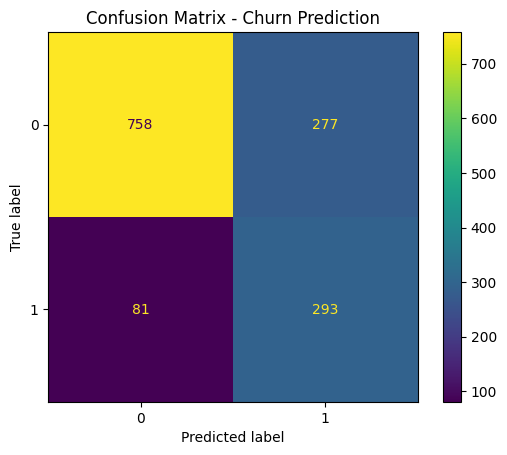

In [ ]:
#Task 13.2 Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Churn Prediction")
plt.show()

In [ ]:
#Task 13.3 Precision / Recall / F1
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.794889992902768
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



**PHASE 14 - Key Insights**

**Key Insights**

*   Customers with shorter tenure are more likely to churn
*   Month-to-month contracts show the highest churn rates
*   Higher monthly charges are associated with higher churn
*   Customers with high churn scores are more likely to leave
*   High-value (CLTV) customers leaving creates major business loss
*   Customers on month-to-month contracts show higher churn because they have lower commitment and higher flexibility to switch providers.


**PHASE 15 - Business Recommendations**

**Business Recommendations**

*   Focus on improving early customer experience (first few months)
*   Encourage long-term contracts to reduce churn
*   Monitor high monthly charge customers for dissatisfaction
*   Target high-risk customers using churn score
*   Prioritize retention of high-CLTV customers